## Part I: Linear Classifier By Hand (Guided)


In [9]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys, os

### 1.1 Get the data

In [11]:
df = pd.read_csv('/content/gdrive/MyDrive/data/intro_ml_2025/ml_tutorial_2_calo_shower_data.csv')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   shower_depth  100000 non-null  float64
 1   shower_width  100000 non-null  float64
 2   type          100000 non-null  object 
dtypes: float64(2), object(1)
memory usage: 2.3+ MB


### 1.2 Data pre-processing

#### 1.2.1 Explore the Data

In [13]:
df.shape

(100000, 3)

***We have 10000 observations and 3 columns which are:***

In [14]:
df.columns

Index(['shower_depth', 'shower_width', 'type'], dtype='object')

In [15]:
df.head(3)

,shower_depth,shower_width,type
0,102.726547,41.060509,hadron
1,55.953644,19.107106,electron
2,76.237938,21.859595,electron


In [16]:
df.describe()

,shower_depth,shower_width
count,100000.000000,100000.000000
mean,99.847703,25.060322
std,31.360512,9.073636
min,0.013479,0.139829
25%,80.005289,18.726105
50%,97.648121,22.890813
75%,121.048161,30.209608
max,222.651768,73.082693


#### 1.2.2 Labels to Binary

In [17]:
df.loc[df["type"] == "hadron", "y"] = 0
df.loc[df["type"] == "electron", "y"] = 1

#### 1.2.3 Create Feature Matrix $X$

In [18]:
df =  df.drop("type",axis=1)
y = df[["y"]].astype(np.float64).to_numpy()
X =  df.drop("y",axis=1).to_numpy()
# Check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000, 2)
y shape: (100000, 1)


#### 1.2.4 Train/Test Split with sklearn
Split the dataset into training and testing sets using 80/20 proportion. For this, copy paste the following in your code:


In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2 ,random_state =42)
# Check shapes
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test: {y_test.shape}")

X_train: (80000, 2), y_train: (80000, 1)
X_test:  (20000, 2),  y_test: (20000, 1)


#### 1.2.5 Feature Scaling
Let's scale our input features using the standardization method.

***Datasets with features on different scales or imbalanced variables should be scaled to ensure that no single variable dominates the learning process and to improve convergence stability.***


In [20]:
# Get mean and std from training data
mean_train = X_train.mean(axis=0)
std_train = X_train.std(axis=0)

# Standardize training
X_train_scaled = (X_train - mean_train)/std_train
# Standardize test data
X_test_scaled  = (X_test - mean_train)/std_train

# Check
print("X_train_scaled mean:", X_train_scaled.mean(axis=0))
print("X_train_scaled std:", X_train_scaled.std(axis=0))

X_train_scaled mean: [-8.41370723e-15 -3.58326327e-14]
X_train_scaled std: [1. 1.]


In [21]:
X_train_scaled

array([[-0.30406953,  0.4683513 ],
       [-1.37175553, -1.42849437],
       [-0.18884122, -0.79198935],
       ...,
       [ 1.41294579,  0.84466537],
       [-1.99158594, -1.01309206],
       [-0.68304672, -0.64823356]])


#### 1.2.6 Feature Matrix Augmentation

In [22]:
X_train_aug = np.hstack((np.ones((len(X_train_scaled),1)), X_train_scaled))
X_test_aug  = np.hstack((np.ones((len(X_test_scaled),1)), X_test_scaled))
print(X_train_aug)

[[ 1.         -0.30406953  0.4683513 ]
 [ 1.         -1.37175553 -1.42849437]
 [ 1.         -0.18884122 -0.79198935]
 ...
 [ 1.          1.41294579  0.84466537]
 [ 1.         -1.99158594 -1.01309206]
 [ 1.         -0.68304672 -0.64823356]]


### 1.3 Functions

#### 1.3.1 Hypothesis Function

In [23]:
def lin_sum(X, thetas):
    """
    Compute the linear combination of input features and parameters.

    Parameters
    ----------
    X : array-like, shape (m_samples, n_features+1)
        Input features (already augmented with a column of ones for bias).
    thetas : array-like, shape (n_features+1,)
        Parameter vector including bias term.

    Returns
    -------
    ndarray, shape (m_samples, 1)
        Linear sum for each sample.
    """

    # My code here
    sum = np.dot(X,thetas)
    return sum


#### 1.3.2 Logistic Function


Consider the linear assumption

$$
\boldsymbol{x} \cdot \boldsymbol{\theta}  = \theta_0 + \theta_1 x_1 + \cdots + \theta_n x_n
$$

as input to the sigmoid function $\sigma$.

Recall that

$$
h_\boldsymbol{\theta} (\boldsymbol{x}^{(i)})
= \sigma \big( \boldsymbol{x}^{(i)} \cdot \boldsymbol{\theta} \big)
= \frac{1}{1 + e^{- \boldsymbol{x}^{(i)} \cdot \boldsymbol{\theta} }}
$$


In [24]:
def sigmoid(z):
  z = np.clip(z, 1e-15, 1 - 1e-15)
  sigmoid_value = 1/(1 + np.exp(-z))
  return sigmoid_value


#### 1.3.3 Partial Derivatives of Cross-Entropy Cost Function

The cost function derivativesis :

$$
\frac{\partial}{\partial \theta_j} J(\boldsymbol{\theta})
= \frac{1}{m} \sum_{i=1}^{m} \Big( h_\boldsymbol{\theta}(\boldsymbol{x}^{(i)}) - y^{(i)} \Big) x_j^{(i)}
$$


In [25]:
def gradient_cross_entropy(y_true, y_pred, X):
    """
    Compute the gradient vector of the cross-entropy cost function.

    Parameters
    ----------
    y_true : array-like, shape (m,) or (m,1)
        Binary target (0 or 1) for each sample.
    y_pred : array-like, shape (m,) or (m,1)
        Predicted score for each sample.
    X : array-like, shape (m, n_features+1)
        Input features, already augmented with a column of ones for bias.

    Returns
    -------
    ndarray, shape (n_features+1, 1)
        Column vector of partial derivatives with respect to each model parameter.
    """
    m= len(y_true)
    diff = y_pred - y_true
    gradient = np.dot(X.T, diff)
    return gradient/m



#### 1.3.4 Cross-Entropy Cost Function

$$
J(\boldsymbol{\theta}) = - \frac{1}{m} \sum_{i=1}^{m}
\Big[ y^{(i)} \log(h_\theta(x^{(i)})) +
(1 - y^{(i)}) \log(1 - h_\theta(x^{(i)})) \Big]
$$


In [26]:
def cross_entropy_cost(y_true, y_pred):
    # My code here
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15) # avoid zero in log
    ent_cost = -np.sum(y_true*np.log(y_pred) + (1-y_true)*np.log(1-y_pred))/len(y_true)
    return ent_cost

In [27]:
def should_print_iteration(iter_index, first_step, second_step, index_changing_step):
    """
    Trigger a print if iter_index matches step rules:
    print every `first_step` iterations before `index_changing_step`,
    then every `second_step` iterations afterwards.
    """
    if first_step <= 0 or second_step <= 0:
        raise ValueError("Steps must be positive integers.")

    if iter_index == 0:
        return True  # Always print at the first iteration

    if iter_index <= index_changing_step:
        return iter_index % first_step == 0
    else:
        return iter_index % second_step == 0

In [28]:
np.shape(X_test_aug)

(20000, 3)

### 1.4 Classifier Loop

In [29]:
# Hyperparameters
alpha       = 0.001   # learning rate
N           = 10000  # maximum number of iterations
epsilon     = 1e-6   # tolerance threshold for gradient norm (stopping criterion)
cost_tol    = 1e-8   # tolerance threshold for cost drop (stop. criterion)
cost_change = np.inf # initialize cost change for first iteration

# Number of features + 1 (number of columns in X)
m, n_param = np.shape(X_train_aug)

# Initialization of theta vector
thetas = np.zeros((n_param, 1))

# Storing cost values for train and test datasets
costs_train = []
costs_test  = []

print("Starting gradient descent\n")

# -------------------
#   Start iterations
# -------------------
for iter_idx in range(N):
    # Get predictions (hypothesis function)
    # Apply sigmoid on X_train_aug and X_test_aug
    y_pred_train = sigmoid(lin_sum(X_train_aug,thetas))
    y_pred_test = sigmoid(lin_sum(X_test_aug,thetas))
    # Calculate and store costs with train and test datasets
    cost_train = cross_entropy_cost(y_train, y_pred_train)
    cost_test  = cross_entropy_cost(y_test, y_pred_test)
    costs_train.append(cost_train)
    costs_test.append(cost_test)

    # My code here for gradient computation & parameter update
    grad_cost = gradient_cross_entropy(y_train,y_pred_train,X_train_aug)
    grad_cost_norm = np.linalg.norm(grad_cost)
    thetas = thetas - alpha*grad_cost
    # Cost change (for early stopping & printing)
    if iter_idx > 0:
        cost_change = cost_train - costs_train[-2]

    # Print selected iterations
    if should_print_iteration(iter_idx, 100, 1000, 1000):
        print(
            f"Iter {iter_idx:>4}\t"
            f"‖grad‖ = {grad_cost_norm:.4e}\t"
            f"Train cost = {cost_train:.5e}\t"
            f"Cost change = {cost_change:>+10.2e}\t"
            f"Test cost = {cost_test:.5e}"
        )

    # Exit conditions
    if np.all(np.abs(grad_cost_norm) < epsilon):
      print(f"Stop at iteration {i}, gradient too small")
      break

print(f'\nEnd of gradient descent after {iter_idx+1} iterations')

print('Optimized parameters:')
for j in range(len(thetas)):
    print(f'\tParameter {j} = {thetas[j,0]:.4f}')

Starting gradient descent

Iter    0	‖grad‖ = 4.2596e-01	Train cost = 6.93147e-01	Cost change =       +inf	Test cost = 6.93147e-01
Iter  100	‖grad‖ = 4.1976e-01	Train cost = 6.85106e-01	Cost change =  -7.81e-05	Test cost = 6.85060e-01
Iter  200	‖grad‖ = 4.1378e-01	Train cost = 6.77528e-01	Cost change =  -7.36e-05	Test cost = 6.77439e-01
Iter  300	‖grad‖ = 4.0803e-01	Train cost = 6.70391e-01	Cost change =  -6.93e-05	Test cost = 6.70259e-01
Iter  400	‖grad‖ = 4.0251e-01	Train cost = 6.63668e-01	Cost change =  -6.53e-05	Test cost = 6.63495e-01
Iter  500	‖grad‖ = 3.9723e-01	Train cost = 6.57336e-01	Cost change =  -6.15e-05	Test cost = 6.57124e-01
Iter  600	‖grad‖ = 3.9219e-01	Train cost = 6.51372e-01	Cost change =  -5.79e-05	Test cost = 6.51122e-01
Iter  700	‖grad‖ = 3.8738e-01	Train cost = 6.45754e-01	Cost change =  -5.45e-05	Test cost = 6.45467e-01
Iter  800	‖grad‖ = 3.8280e-01	Train cost = 6.40463e-01	Cost change =  -5.13e-05	Test cost = 6.40140e-01
Iter  900	‖grad‖ = 3.7849e-01	Train c

### 1.5 Plot cost versus epochs

In [30]:
def plot_cost_vs_iter(train_costs, test_costs, title="Gradient Descent: Cost evolution"):

  fig, ax = plt.subplots(figsize=(8, 6))

  iters = np.arange(1,len(train_costs)+1)

  ax.plot(iters, train_costs, color='red', lw=1, label='Training set')
  ax.plot(iters, test_costs, color='blue', lw=1, label='Testing set')

  ax.set_xlabel("Number of iterations")
  ax.set_ylabel(r"Cost $J(\theta)$", rotation="horizontal")
  ax.yaxis.set_label_coords(-0.2, 0.5)

  ax.legend(loc="upper right", frameon=False)
  ax.set_title(title, fontsize=18, pad=20)
  plt.show()

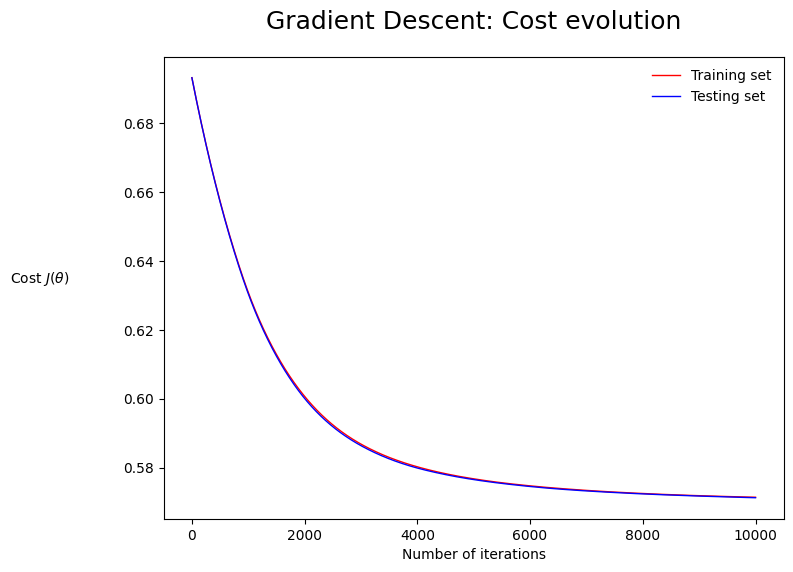

In [31]:
plot_cost_vs_iter(costs_train, costs_test)

#### 1.5.1 Plot Interpretation
***he model did not overfit the data since the training and test costs remained close. From the curve, we can see that they are almost overlapping.***


#### 1.5.2 Cost gap?
***If there were a larger gap between the training and test cost values, it would mean the model is overfitting: it learns the training data too well (low training cost) but fails to generalize to test data (high test cost).***

### 1.6 Performance Measures

#### 1.6.1 Binary Predictions

In [32]:
def make_predictions(thetas, X, boundary=0.5):
    scores = sigmoid(lin_sum(X, thetas)).flatten() # shape (m,)
    return (scores >= boundary).astype(int)

#### 1.6.2 Accuracy

In [62]:
def accuracy(y_true, y_pred):
   # Flatten arrays to 1D to avoid shape issues
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    # Count correct predictions
    correct = np.sum(y_true == y_pred)
    total = y_true.shape[0]
    return correct/total


### 1.6.3 Recall

In [65]:
def recall(y_true, y_pred):
  # Flatten arrays to 1D to avoid shape issues
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn + 1e-15) # avoid zero


In [69]:
y_pred_test_binary = make_predictions(thetas, X_test_aug)

test_accuracy = accuracy(y_test, y_pred_test_binary)
test_recall = recall(y_test, y_pred_test_binary)

print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test Recall:   {test_recall:.2f}")

Test Accuracy: 0.50
Test Recall:   1.00


## Part II: Draw Decision Boundaries